In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

plt.rcParams["figure.dpi"] = 130

# Function for MC Simulation

In [10]:
@njit
def monte_carlo_DLA(height, width, max_particles, p_s, max_steps=200000):
    """
    Monte Carlo simulation.

    Parameters
    ----------
    height, width : int
        Grid size.
    max_particles : int
        Target cluster size, including the seed.
    p_s : float
        Sticking probability.
    max_steps : int
        Maximum number of steps for one walker.

    Returns
    -------
    cluster : 2D int array
        Cluster grid, with occupied sites equal to 1.
    cluster_size : int
        Number of particles in the cluster when the simulation stops.
    """
    np.random.seed(42)

    cluster = np.zeros((height, width), dtype=np.int32)

    # seed at the bottom center
    seed_y = height - 1
    seed_x = width // 2
    cluster[seed_y, seed_x] = 1

    # possible walker moves: right, left, down, up
    moves = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]], dtype=np.int32)

    cluster_size = 1
    reached_top = False

    while cluster_size < max_particles and not reached_top:
        # start one walker from a random point at the top boundary
        x = np.random.randint(0, width)
        y = 0

        walker_steps = 0
        while walker_steps < max_steps:
            walker_steps += 1

            # choose one random move
            k = np.random.randint(0, 4)
            dx, dy = moves[k, 0], moves[k, 1]
            x_new = x + dx
            y_new = y + dy

            # periodic boundary in x-direction
            if x_new < 0:
                x_new = width - 1
            elif x_new >= width:
                x_new = 0

            # remove walker if it leaves through top or bottom
            if y_new < 0 or y_new >= height:
                break

            # walker cannot move into the cluster
            if cluster[y_new, x_new] == 1:
                continue

            x, y = x_new, y_new

            # check whether the walker is next to the cluster
            next_to_cluster = False
            for i in range(4):
                nx = x + moves[i, 0]
                ny = y + moves[i, 1]

                if nx < 0:
                    nx = width - 1
                elif nx >= width:
                    nx = 0

                if 0 <= ny < height and cluster[ny, nx] == 1:
                    next_to_cluster = True
                    break

            # attach with probability p_s
            if next_to_cluster:
                if np.random.random() < p_s:
                    cluster[y, x] = 1
                    cluster_size += 1

                    # stop if the cluster reaches the top boundary
                    if y == 0:
                        reached_top = True

                    break

    return cluster, cluster_size


# Function for Plot

In [11]:
def plot_DLA_clusters(clusters, cluster_sizes, title=None):
    """
    Plot clusters for different sticking probabilities.
    """
    ps_list = list(clusters.keys())
    n = len(ps_list)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, p_s in zip(axes, ps_list):
        ax.imshow(clusters[p_s], interpolation="nearest")
        ax.set_title(rf"$p_s={p_s}$, Cluster size = {cluster_sizes[p_s]}")
        ax.set_xticks([])
        ax.set_yticks([])

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()

# Main Part

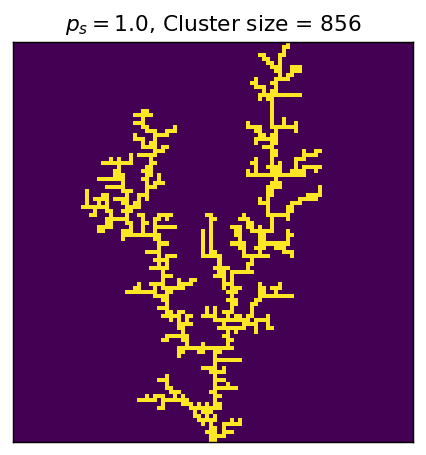

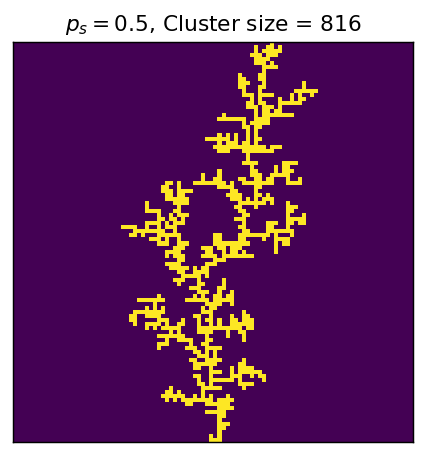

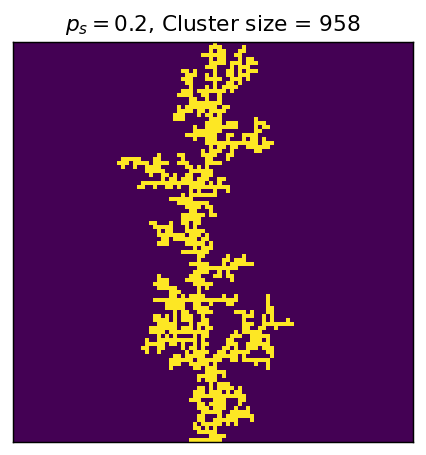

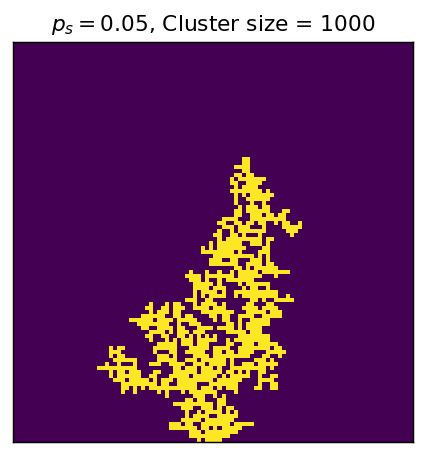

Saved cluster images and arrays to: outputs


In [12]:
height, width = 100, 100
max_particles = 1000

ps_values = [1.0, 0.5, 0.2, 0.05]

clusters = {}
cluster_sizes = {}

for p_s in ps_values:
    cluster, cluster_size = monte_carlo_DLA(height, width, max_particles, p_s)
    clusters[p_s] = cluster
    cluster_sizes[p_s] = cluster_size

outdir = "outputs"
os.makedirs(outdir, exist_ok=True)

for p_s in ps_values:
    cluster = clusters[p_s]
    cluster_size = cluster_sizes[p_s]

    plt.figure(figsize=(4, 4))
    plt.imshow(cluster, interpolation="nearest")
    plt.title(rf"$p_s={p_s}$, Cluster size = {cluster_size}")
    plt.xticks([])
    plt.yticks([])
    plt.show()

    np.save(os.path.join(outdir, f"cluster_ps_{p_s}.npy"), cluster)

    plt.imsave(
        os.path.join(outdir, f"cluster_ps_{p_s}_steps_{cluster_size}.png"),
        cluster
    )

print("Saved cluster images and arrays to:", outdir)